# Raw Data Exploration (Without Elasticsearch)
This notebook provides a basic Data Science workflow to explore the raw JSONL data directly using standard Python libraries (`pandas`, `matplotlib`, `json`) without relying on an external database.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load and Flatten JSON Data
We'll stream the `jsonl` dataset and extract essential fields to build a tabular DataFrame.

In [2]:
data_path = '../data/ocds.jsonl'
parsed_data = []
LIMIT = 500000  # Number of rows to read for quick EDA

with open(data_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= LIMIT:
            break
        
        try:
            release = json.loads(line)
            
            # Extract nested fields safely
            tender = release.get('tender', {})
            parties = release.get('parties', [])
            
            # Find the buyer
            buyers = [p.get('name') for p in parties if 'buyer' in p.get('roles', [])]
            buyer_name = buyers[0] if buyers else 'Unknown'
            
            parsed_data.append({
                'ocid': release.get('ocid'),
                'release_date': release.get('date'),
                'tender_id': tender.get('id'),
                'procurement_method': tender.get('procurementMethod', 'Unknown'),
                'buyer_name': buyer_name,
                'num_contracts': len(release.get('contracts', [])),
                'num_awards': len(release.get('awards', []))
            })
        except json.JSONDecodeError:
            continue

df = pd.DataFrame(parsed_data)
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce', utc=True)
print(f"Loaded {len(df)} records.")
df.head()

Loaded 184581 records.


,ocid,release_date,tender_id,procurement_method,buyer_name,num_contracts,num_awards
0,ocds-h6vhtk-038ce3,2023-04-28 15:32:31+00:00,Dundonald Building Lot 1,limited,Education Authority NI,2,2
1,ocds-h6vhtk-03aecd,2023-09-06 09:28:02+00:00,DN645577,open,Essex County Council,1,1
2,ocds-h6vhtk-0371cc,2022-09-30 12:35:53+00:00,ocds-h6vhtk-0371cc,open,The Common Services Agency (more commonly know...,2,2
3,ocds-h6vhtk-0419af,2024-02-28 09:24:18+00:00,3954/JN/23,open,UNIVERSITY OF SHEFFIELD,1,1
4,ocds-h6vhtk-04ec11,2025-05-09 12:00:22+00:00,ocds-h6vhtk-04ec11,open,Surrey Heath Borough Council,0,1


## 2. Basic Data Profiling
Check data types, identify missing values, and view high-level descriptive statistics.

In [3]:
# Info about column data types and memory usage
df.info()

# Missing value counts for each field
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 184581 entries, 0 to 184580
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   ocid                184581 non-null  str                
 1   release_date        184581 non-null  datetime64[us, UTC]
 2   tender_id           184581 non-null  str                
 3   procurement_method  184581 non-null  str                
 4   buyer_name          184581 non-null  str                
 5   num_contracts       184581 non-null  int64              
 6   num_awards          184581 non-null  int64              
dtypes: datetime64[us, UTC](1), int64(2), str(4)
memory usage: 9.9 MB


ocid                  0
release_date          0
tender_id             0
procurement_method    0
buyer_name            0
num_contracts         0
num_awards            0
dtype: int64

In [4]:
# High-level descriptive stats for numerical columns
df.describe()

,num_contracts,num_awards
count,184581.000000,184581.000000
mean,1.175468,1.291829
std,11.824598,12.631864
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,2592.000000,2821.000000


## 3. Exploratory Visualizations
Let's visualize some clear patterns: the distribution of different procurement methods and a timeline of when procurements were released.

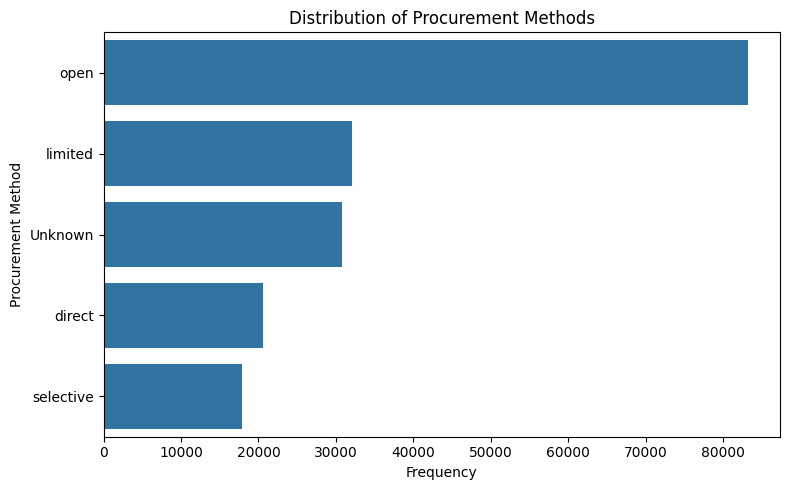

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(
    y='procurement_method', 
    data=df, 
    order=df['procurement_method'].value_counts().index, 
)
plt.title('Distribution of Procurement Methods')
plt.xlabel('Frequency')
plt.ylabel('Procurement Method')
plt.tight_layout()
plt.show()

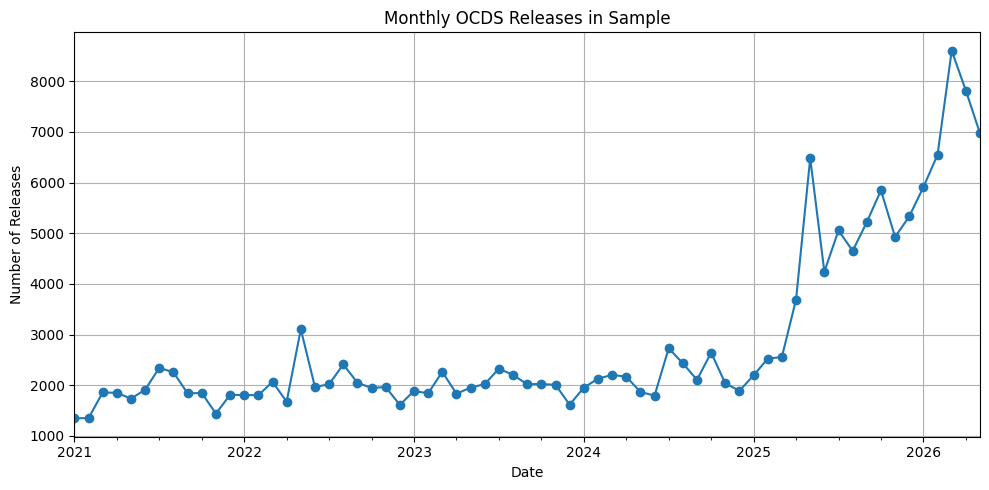

In [6]:
plt.figure(figsize=(10, 5))
# Resample by Month to see trends
df.set_index('release_date').resample('ME').size().plot(kind='line', marker='o')
plt.title('Monthly OCDS Releases in Sample')
plt.xlabel('Date')
plt.ylabel('Number of Releases')
plt.grid(True)
plt.tight_layout()
plt.show()